# Nemotron 3 Nano Omni for Task Mining from Screen Recordings

This Colab demo uses a public desktop-usage recording to show how Nemotron 3 Nano Omni can convert screen activity into task-mining artifacts:

- a task summary
- a sequence of user activities
- a case-level event log
- a process graph that resembles a Celonis process view
- automation opportunities

The source video comes from the [Markov Sample Dataset - 100 Hours](https://huggingface.co/datasets/markov-ai/sample-100-hours), which contains screen recordings, raw mouse/keyboard/app events, metadata, and structured annotations. The model call uses NVIDIA's OpenAI-compatible NIM chat-completions endpoint for `nvidia/nemotron-3-nano-omni-30b-a3b-reasoning`.

No GPU is required in Colab because inference runs through the hosted NIM API. Here is a [quick setup guide](https://github.com/andandandand/practical-computer-vision/blob/main/docs/Setup_NVIDIA_API_KEY.md).


## What This Demonstrates

Task mining observes what users do across desktop applications. In this notebook, a screen recording and a compact telemetry summary are turned into a structured event log. That event log can then feed process mining: `case_id`, `activity`, `timestamp`, resource/application, and transitions.

For a Celonis-style workflow, the key move is:

1. Observe a user session.
2. Infer high-level activities from low-level UI behavior.
3. Convert those activities into event-log rows.
4. Aggregate transitions into a process graph.

The model output is measured evidence, not a hard-coded claim. The sample annotations are kept for validation after inference.


## Setup

Add your NIM key in Colab Secrets as `NVIDIA_API_KEY`.

The notebook installs client and visualization packages. It does not install or run the model in the Colab runtime.


In [ ]:
%pip install -q huggingface_hub pandas pillow opencv-python-headless requests networkx matplotlib


In [ ]:
from __future__ import annotations

import base64
import json
import os
import re
import subprocess
import textwrap
import time
from collections import Counter
from pathlib import Path
from urllib.parse import urlparse

import cv2
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
import requests
from huggingface_hub import hf_hub_download, list_repo_files
from IPython.display import JSON, Markdown, Video, display
from PIL import Image, ImageDraw

pd.set_option("display.max_colwidth", 140)


In [ ]:
def read_secret(name: str) -> str | None:
    value = os.environ.get(name)
    if value:
        return value
    try:
        from google.colab import userdata

        return userdata.get(name)
    except Exception:
        return None


NVIDIA_API_KEY = read_secret("NVIDIA_API_KEY")
NVAI_URL = os.environ.get("NVAI_URL", "https://integrate.api.nvidia.com/v1").rstrip("/")
NANO_OMNI_MODEL = os.environ.get(
    "NANO_OMNI_MODEL",
    "nvidia/nemotron-3-nano-omni-30b-a3b-reasoning",
)

print("NVIDIA_API_KEY:", "set" if NVIDIA_API_KEY else "missing")
print("NVAI_URL:", NVAI_URL)
print("NANO_OMNI_MODEL:", NANO_OMNI_MODEL)


NVIDIA_API_KEY: set
NVAI_URL: https://integrate.api.nvidia.com/v1
NANO_OMNI_MODEL: nvidia/nemotron-3-nano-omni-30b-a3b-reasoning


## Dataset Sample

The pinned sample is a productivity workflow titled **SaaS product submission and listing workflow**. It is small enough for Colab but has useful task-mining signals: app switching, browser navigation, local site review, backlink verification, and directory-submission work.

If the pinned file moves, the code falls back to another productivity clip from the same dataset.


In [ ]:
DATASET_REPO = "markov-ai/sample-100-hours"
PINNED_SAMPLE_FOLDER = "productivity/0b927e78-a2d3-4e39-a9b6-4fb6502bd7ca"
PINNED_VIDEO = f"{PINNED_SAMPLE_FOLDER}/clip.mp4"


def resolve_sample_folder(repo_id: str, pinned_video: str) -> str:
    files = set(list_repo_files(repo_id=repo_id, repo_type="dataset"))
    if pinned_video in files:
        return pinned_video.rsplit("/", 1)[0]

    video_files = sorted(path for path in files if path.startswith("productivity/") and path.endswith("/clip.mp4"))
    if not video_files:
        video_files = sorted(path for path in files if path.endswith("/clip.mp4"))
    if not video_files:
        raise RuntimeError(f"No clip.mp4 files found in {repo_id}.")
    return video_files[0].rsplit("/", 1)[0]


SAMPLE_FOLDER = resolve_sample_folder(DATASET_REPO, PINNED_VIDEO)
VIDEO_FILE = f"{SAMPLE_FOLDER}/clip.mp4"
EVENTS_FILE = f"{SAMPLE_FOLDER}/events.json"
METADATA_FILE = f"{SAMPLE_FOLDER}/metadata.json"
NARRATION_FILE = f"{SAMPLE_FOLDER}/narration.json"
PUBLIC_VIDEO_URL = f"https://huggingface.co/datasets/{DATASET_REPO}/resolve/main/{VIDEO_FILE}"

print("Sample folder:", SAMPLE_FOLDER)
print("Public video URL:", PUBLIC_VIDEO_URL)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Sample folder: productivity/0b927e78-a2d3-4e39-a9b6-4fb6502bd7ca
Public video URL: https://huggingface.co/datasets/markov-ai/sample-100-hours/resolve/main/productivity/0b927e78-a2d3-4e39-a9b6-4fb6502bd7ca/clip.mp4


In [ ]:
def download_dataset_file(filename: str) -> Path:
    return Path(
        hf_hub_download(
            repo_id=DATASET_REPO,
            repo_type="dataset",
            filename=filename,
        )
    )


video_path = download_dataset_file(VIDEO_FILE)
events_path = download_dataset_file(EVENTS_FILE)
metadata_path = download_dataset_file(METADATA_FILE)
narration_path = download_dataset_file(NARRATION_FILE)

metadata = json.loads(metadata_path.read_text())
narration = json.loads(narration_path.read_text())

display(JSON(metadata))
print(f"Video path: {video_path}")
print(f"Video size: {video_path.stat().st_size / 1e6:.1f} MB")


productivity/0b927e78-a2d3-4e39-a9b6-4fb(…):   0%|          | 0.00/27.6M [00:00<?, ?B/s]

events.json: 0.00B [00:00, ?B/s]

metadata.json:   0%|          | 0.00/525 [00:00<?, ?B/s]

narration.json: 0.00B [00:00, ?B/s]

<IPython.core.display.JSON object>

Video path: /root/.cache/huggingface/hub/datasets--markov-ai--sample-100-hours/snapshots/07a0ae0812fd8c2d1ee286be8a66080277454999/productivity/0b927e78-a2d3-4e39-a9b6-4fb6502bd7ca/clip.mp4
Video size: 27.6 MB


## Build a Short Clip

The full recording is longer than needed for a quick demo. This cell extracts a 45-second window, lowers the frame rate, scales the video, and removes audio. The resulting MP4 is sent inline to the NIM API.

The chosen window starts after the user opens the browser and captures a sequence of site review, tab switching, and backlink verification.


In [ ]:
CLIP_START_S = 26
CLIP_DURATION_S = 45
CLIP_FPS = 4
CLIP_WIDTH = 960

short_video_path = Path("/content/task_mining_short_clip.mp4")

cmd = [
    "ffmpeg",
    "-y",
    "-ss",
    str(CLIP_START_S),
    "-i",
    str(video_path),
    "-t",
    str(CLIP_DURATION_S),
    "-vf",
    f"fps={CLIP_FPS},scale={CLIP_WIDTH}:-2",
    "-c:v",
    "libx264",
    "-preset",
    "veryfast",
    "-crf",
    "30",
    "-an",
    str(short_video_path),
]

started = time.perf_counter()
proc = subprocess.run(cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True)
if proc.returncode != 0:
    print(proc.stderr[-3000:])
    raise RuntimeError("ffmpeg failed to create the short clip.")

elapsed = time.perf_counter() - started
print(f"Created {short_video_path} in {elapsed:.1f}s")
print(f"Short clip size: {short_video_path.stat().st_size / 1e6:.2f} MB")
display(Video(str(short_video_path), embed=True, width=900))


Created /content/task_mining_short_clip.mp4 in 10.1s
Short clip size: 0.40 MB


## Storyboard Preview

The storyboard is not sent to the API. It gives a quick human check of the visual signal in the sampled clip.


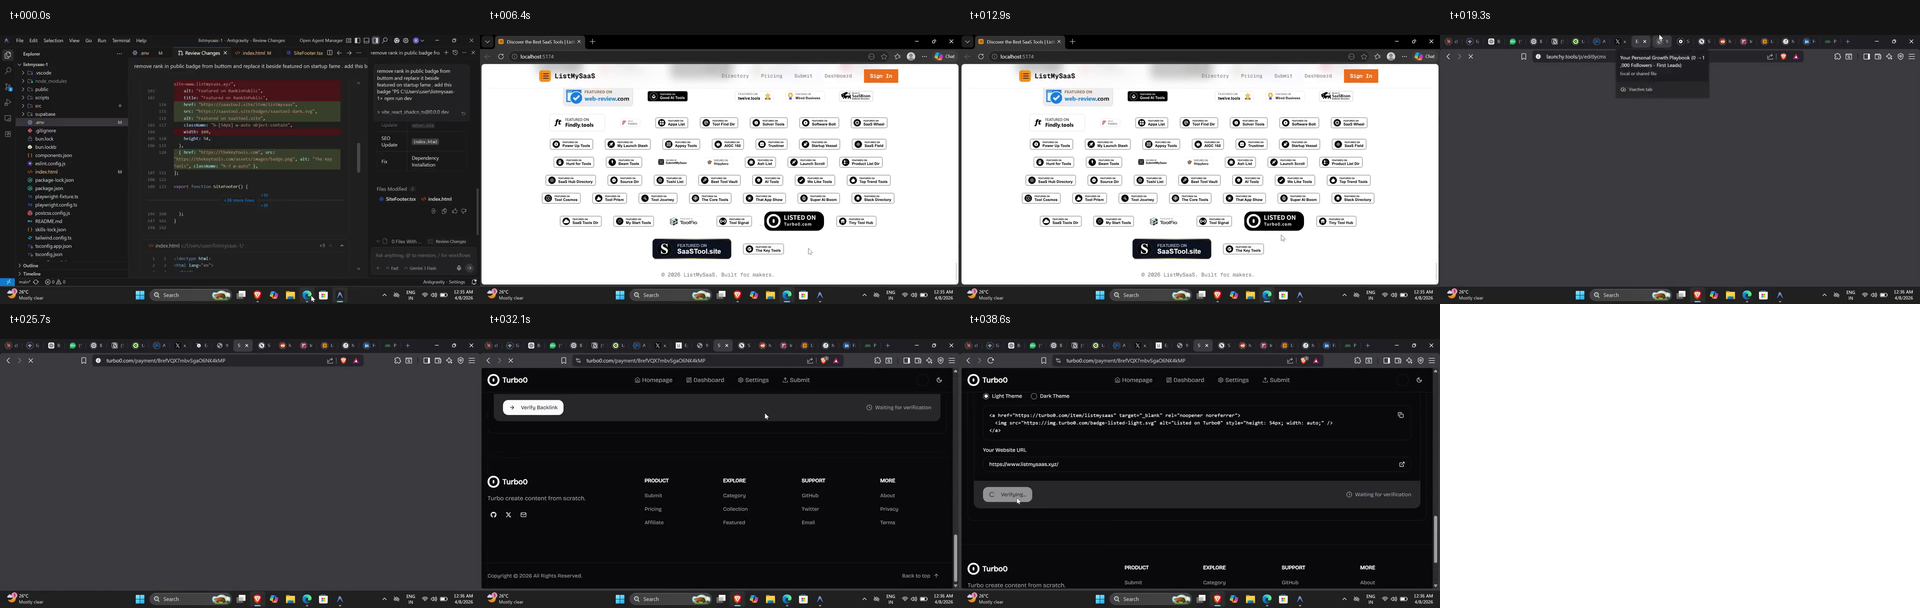

/content/task_mining_storyboard.jpg


In [ ]:
def sample_video_frames(path: Path, frame_count: int = 8) -> list[tuple[float, Image.Image]]:
    cap = cv2.VideoCapture(str(path))
    if not cap.isOpened():
        raise RuntimeError(f"Could not open video: {path}")

    fps = cap.get(cv2.CAP_PROP_FPS) or CLIP_FPS
    total_frames = cap.get(cv2.CAP_PROP_FRAME_COUNT) or 0
    duration = total_frames / fps if total_frames else CLIP_DURATION_S

    timestamps = [duration * i / max(frame_count - 1, 1) for i in range(frame_count)]
    frames: list[tuple[float, Image.Image]] = []

    for t in timestamps:
        cap.set(cv2.CAP_PROP_POS_MSEC, t * 1000)
        ok, frame = cap.read()
        if not ok:
            continue
        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames.append((t, Image.fromarray(rgb)))

    cap.release()
    return frames


def make_storyboard(frames: list[tuple[float, Image.Image]], cols: int = 4, cell_width: int = 480) -> Image.Image:
    resized = []
    label_h = 34
    for t, img in frames:
        ratio = cell_width / img.width
        cell_h = int(img.height * ratio)
        thumb = img.resize((cell_width, cell_h), Image.Resampling.LANCZOS)
        canvas = Image.new("RGB", (cell_width, cell_h + label_h), "white")
        canvas.paste(thumb, (0, label_h))
        draw = ImageDraw.Draw(canvas)
        draw.rectangle((0, 0, cell_width, label_h), fill=(20, 20, 20))
        draw.text((10, 9), f"t+{t:05.1f}s", fill="white")
        resized.append(canvas)

    rows = (len(resized) + cols - 1) // cols
    cell_h = resized[0].height
    board = Image.new("RGB", (cols * cell_width, rows * cell_h), "white")
    for idx, img in enumerate(resized):
        x = (idx % cols) * cell_width
        y = (idx // cols) * cell_h
        board.paste(img, (x, y))
    return board


storyboard_frames = sample_video_frames(short_video_path, frame_count=8)
storyboard = make_storyboard(storyboard_frames)
storyboard_path = Path("/content/task_mining_storyboard.jpg")
storyboard.save(storyboard_path, quality=88)
display(storyboard)
print(storyboard_path)


## Compact Desktop Telemetry

The dataset includes raw events as JSONL. For the model prompt, keep a compact summary: event counts, app switches, and click density. Avoid sending raw keystrokes or long payloads.


In [ ]:
def read_jsonl(path: Path) -> list[dict]:
    rows = []
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows


def short_text(value, limit: int = 120):
    if value is None:
        return None
    text = str(value).replace("\n", " ").strip()
    return text[:limit]


def domain_only(url):
    if not url:
        return None
    parsed = urlparse(url)
    return parsed.netloc or None


raw_events = read_jsonl(events_path)
first_ts = min(float(event["timestamp"]) for event in raw_events if "timestamp" in event)

for event in raw_events:
    if "timestamp" in event:
        event["t_rel_s"] = (float(event["timestamp"]) - first_ts) / 1000.0

window_end_s = CLIP_START_S + CLIP_DURATION_S
window_events = [
    event
    for event in raw_events
    if CLIP_START_S <= float(event.get("t_rel_s", -1)) <= window_end_s
]

event_counts = Counter(event.get("type", "unknown") for event in window_events)
app_names = [
    event.get("name") or event.get("appName")
    for event in window_events
    if event.get("name") or event.get("appName")
]
top_apps = Counter(app_names).most_common(10)

app_switches = [
    {
        "t_s": round(event["t_rel_s"], 2),
        "app": short_text(event.get("name")),
        "window_title": short_text(event.get("windowTitle")),
        "domain": domain_only(event.get("browserUrl")),
    }
    for event in window_events
    if event.get("type") == "active_app"
][:20]

clicks_by_app = Counter(
    event.get("appName") or "unknown"
    for event in window_events
    if event.get("type") == "click" and event.get("isDown") is True
)

telemetry_summary = {
    "clip_window_s": {"start": CLIP_START_S, "end": window_end_s, "duration": CLIP_DURATION_S},
    "event_count": len(window_events),
    "event_type_counts": dict(event_counts.most_common()),
    "top_apps": dict(top_apps),
    "clicks_by_app": dict(clicks_by_app.most_common(10)),
    "app_switches": app_switches,
}

display(pd.DataFrame(app_switches))
print(json.dumps(telemetry_summary, indent=2)[:5000])


,t_s,app,window_title,domain
0,26.69,Microsoft Edge,ListMySaaS — Discover the Best SaaS Tools - Personal - Microsoft? Edge,None
1,41.46,Brave Browser,Python Skill Up - Brave,None
2,53.55,Windows Explorer,,None
3,53.77,Microsoft Edge,Discover the Best SaaS Tools | ListMySaaS - Personal - Microsoft? Edge,None
4,57.20,Windows Explorer,,None
5,57.42,Brave Browser,Submit your product (2/3) - Turbo0 - Brave,None


{
  "clip_window_s": {
    "start": 26,
    "end": 71,
    "duration": 45
  },
  "event_count": 449,
  "event_type_counts": {
    "mouse_move": 340,
    "app_unhidden": 39,
    "app_hidden": 32,
    "click": 16,
    "window_resized": 10,
    "active_app": 6,
    "window_title_changed": 6
  },
  "top_apps": {
    "Brave Browser": 229,
    "Microsoft Edge": 205,
    "Windows Explorer": 10,
    "Antigravity": 5
  },
  "clicks_by_app": {
    "Brave Browser": 5,
    "Microsoft Edge": 2,
    "Antigravity": 1
  },
  "app_switches": [
    {
      "t_s": 26.69,
      "app": "Microsoft Edge",
      "window_title": "ListMySaaS \u2014 Discover the Best SaaS Tools - Personal - Microsoft? Edge",
      "domain": null
    },
    {
      "t_s": 41.46,
      "app": "Brave Browser",
      "window_title": "Python Skill Up - Brave",
      "domain": null
    },
    {
      "t_s": 53.55,
      "app": "Windows Explorer",
      "window_title": "",
      "domain": null
    },
    {
      "t_s": 53.77,
      "ap

## NIM API Helper

Nemotron 3 Nano Omni accepts `video_url` inputs in the OpenAI-compatible chat-completions payload. This notebook sends the short MP4 as a base64 data URL, which avoids relying on the model server to fetch a Hugging Face URL.

The helper mirrors the OCR cookbook pattern: Colab Secret, OpenAI-compatible endpoint, no hard-coded credentials, JSON response mode, and optional thinking control through `chat_template_kwargs`.


In [ ]:
SYSTEM_PROMPT = (
    "You are a task-mining analyst. Convert screen-recording evidence into concise, "
    "structured task-mining events. Return a JSON object and no extra text."
)


def media_to_data_url(path: Path, mime_type: str) -> str:
    payload = base64.b64encode(path.read_bytes()).decode("utf-8")
    return f"data:{mime_type};base64,{payload}"


def extract_text(response_json: dict) -> str:
    choice = response_json["choices"][0]
    message = choice.get("message", {})
    content = message.get("content", "")
    if isinstance(content, list):
        parts = []
        for item in content:
            if isinstance(item, dict):
                parts.append(item.get("text", ""))
            else:
                parts.append(str(item))
        content = "\n".join(parts)
    return re.sub(r"<think>.*?</think>", "", str(content), flags=re.DOTALL).strip()


def extract_json_object(text: str) -> dict:
    text = text.strip()
    try:
        return json.loads(text)
    except json.JSONDecodeError:
        pass

    fenced = re.search(r"```(?:json)?\s*(\{.*?\})\s*```", text, flags=re.DOTALL)
    if fenced:
        return json.loads(fenced.group(1))

    start = text.find("{")
    end = text.rfind("}")
    if start >= 0 and end > start:
        return json.loads(text[start : end + 1])

    raise ValueError("No JSON object found in model response.")


def call_nemotron_task_mining(
    prompt: str,
    video_path: Path,
    *,
    reasoning: bool = False,
    num_frames: int = 16,
    max_tokens: int = 4096,
    temperature: float = 0.2,
) -> dict:
    if not NVIDIA_API_KEY:
        raise RuntimeError("Set NVIDIA_API_KEY in Colab Secrets or as an environment variable.")

    size_mb = video_path.stat().st_size / 1e6
    if size_mb > 15:
        raise ValueError(
            f"The inline clip is {size_mb:.1f} MB. Reduce CLIP_DURATION_S, CLIP_WIDTH, or CLIP_FPS."
        )

    headers = {
        "Authorization": f"Bearer {NVIDIA_API_KEY}",
        "Accept": "application/json",
        "Content-Type": "application/json",
    }
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {
            "role": "user",
            "content": [
                {"type": "text", "text": prompt},
                {"type": "video_url", "video_url": {"url": media_to_data_url(video_path, "video/mp4")}},
            ],
        },
    ]
    body = {
        "model": NANO_OMNI_MODEL,
        "messages": messages,
        "temperature": temperature,
        "max_tokens": max_tokens,
        "stream": False,
        "response_format": {"type": "json_object"},
        "chat_template_kwargs": {"enable_thinking": reasoning},
        "media_io_kwargs": {"video": {"num_frames": int(num_frames), "fps": -1}},
    }
    if reasoning:
        body["top_p"] = 0.95
    else:
        body["top_k"] = 1

    url = f"{NVAI_URL}/chat/completions"
    response = requests.post(url, headers=headers, json=body, timeout=300)
    if not response.ok:
        print(response.text[:4000])
        response.raise_for_status()
    return response.json()


## Prompt the Model

The prompt asks for a task-mining event log, not a generic video caption. The raw annotations from the dataset are not included in this prompt. They are used later as a sanity check.


In [ ]:
task_mining_prompt = f'''
Analyze this short desktop screen recording as a task-mining sample.

Context:
- Dataset session title: {metadata.get("title")}
- Dataset category: {metadata.get("category")}
- Platform: {metadata.get("platform")}
- Original session description: {metadata.get("description")}
- The video starts at t={CLIP_START_S}s in the original recording and lasts {CLIP_DURATION_S}s.

Compact telemetry from the same time window:
{json.dumps(telemetry_summary, indent=2)}

Return JSON with this schema:
{{
  "task_summary": "one paragraph summary of the business task",
  "case_id": "stable case id for this user session",
  "observed_applications": ["application or website names"],
  "task_mining_events": [
    {{
      "event_index": 1,
      "start_s": 0.0,
      "end_s": 5.0,
      "activity": "short Celonis-style activity label",
      "application": "app or site",
      "event_type": "app_switch | page_review | form_entry | click | verification | navigation | other",
      "ui_evidence": "visible evidence from the video",
      "confidence": 0.0
    }}
  ],
  "process_model_edges": [
    {{
      "from_activity": "activity A",
      "to_activity": "activity B",
      "evidence": "visible or telemetry evidence for this transition"
    }}
  ],
  "task_to_process_mining_mapping": {{
    "case_id_column": "case_id",
    "activity_column": "activity",
    "timestamp_column": "start_s",
    "resource_column": "application",
    "notes": "how this task-mining output could become an event log"
  }},
  "automation_opportunities": [
    {{
      "opportunity": "short name",
      "why_it_matters": "business reason",
      "candidate_signal": "what the UI or telemetry showed"
    }}
  ],
  "ambiguities": ["things that need more frames, UI telemetry, or user context"]
}}

Use timestamps relative to the short clip, not the original full video.
Return a JSON object and no extra text.
'''

print(task_mining_prompt[:4000])



Analyze this short desktop screen recording as a task-mining sample.

Context:
- Dataset session title: SaaS product submission and listing workflow
- Dataset category: productivity
- Platform: windows
- Original session description: User completed multi-step SaaS product submission across multiple platforms, filling forms on SaaSTool and Turbo0 while coordinating with ListMySaaS directory and documenting progress.
- The video starts at t=26s in the original recording and lasts 45s.

Compact telemetry from the same time window:
{
  "clip_window_s": {
    "start": 26,
    "end": 71,
    "duration": 45
  },
  "event_count": 449,
  "event_type_counts": {
    "mouse_move": 340,
    "app_unhidden": 39,
    "app_hidden": 32,
    "click": 16,
    "window_resized": 10,
    "active_app": 6,
    "window_title_changed": 6
  },
  "top_apps": {
    "Brave Browser": 229,
    "Microsoft Edge": 205,
    "Windows Explorer": 10,
    "Antigravity": 5
  },
  "clicks_by_app": {
    "Brave Browser": 5,
   

In [ ]:
response_json = call_nemotron_task_mining(
    task_mining_prompt,
    short_video_path,
    reasoning=False,
    num_frames=16,
    max_tokens=4096,
)

raw_model_text = extract_text(response_json)
task_mining_result = extract_json_object(raw_model_text)

result_path = Path("/content/nemotron_task_mining_result.json")
result_path.write_text(json.dumps(task_mining_result, indent=2), encoding="utf-8")

display(JSON(task_mining_result))
print(f"Saved result to {result_path}")


<IPython.core.display.JSON object>

Saved result to /content/nemotron_task_mining_result.json


## Convert the Model Output to an Event Log

This turns inferred activities into a case-level event log with Celonis-style columns.


In [ ]:
events = task_mining_result.get("task_mining_events", [])
events_df = pd.DataFrame(events)

if events_df.empty:
    raise RuntimeError("The model returned no task_mining_events.")

case_id = task_mining_result.get("case_id") or metadata.get("workflow_id") or SAMPLE_FOLDER.split("/")[-1]
events_df.insert(0, "case_id", case_id)
events_df["source_video"] = VIDEO_FILE
events_df["model"] = NANO_OMNI_MODEL

event_log_path = Path("/content/nemotron_task_mining_event_log.csv")
events_df.to_csv(event_log_path, index=False)

display(events_df)
print(f"Saved event log to {event_log_path}")


,case_id,event_index,start_s,end_s,activity,application,event_type,ui_evidence,confidence,source_video,model
0,SaaS_Product_Submission_001,1,0.0,5.0,review code and navigate to ListMySaaS,ListMySaaS,page_review,Code editor showing HTML/CSS for badge button and website displaying 'ListMySaaS' with featured tools,0.95,productivity/0b927e78-a2d3-4e39-a9b6-4fb6502bd7ca/clip.mp4,nvidia/nemotron-3-nano-omni-30b-a3b-reasoning
1,SaaS_Product_Submission_001,2,5.0,10.0,click on 'Listed on Turbo0.com' badge,ListMySaaS,click,Cursor hovering over 'LISTED ON Turbo0.com' badge on ListMySaaS homepage,0.90,productivity/0b927e78-a2d3-4e39-a9b6-4fb6502bd7ca/clip.mp4,nvidia/nemotron-3-nano-omni-30b-a3b-reasoning
2,SaaS_Product_Submission_001,3,10.0,15.0,open new tab and navigate to Turbo0,Brave Browser,navigation,New tab opened with URL 'turbo0.com' and page loading,0.85,productivity/0b927e78-a2d3-4e39-a9b6-4fb6502bd7ca/clip.mp4,nvidia/nemotron-3-nano-omni-30b-a3b-reasoning
3,SaaS_Product_Submission_001,4,15.0,20.0,select 'Submit' option in Turbo0 menu,Turbo0,click,Dropdown menu showing 'Submit' option selected,0.80,productivity/0b927e78-a2d3-4e39-a9b6-4fb6502bd7ca/clip.mp4,nvidia/nemotron-3-nano-omni-30b-a3b-reasoning
4,SaaS_Product_Submission_001,5,20.0,25.0,enter website URL in Turbo0 form,Turbo0,form_entry,Text field containing 'https://listmysaas.xyz/',0.95,productivity/0b927e78-a2d3-4e39-a9b6-4fb6502bd7ca/clip.mp4,nvidia/nemotron-3-nano-omni-30b-a3b-reasoning
5,SaaS_Product_Submission_001,6,25.0,30.0,click 'Verify' button,Turbo0,click,Button labeled 'Verify' clicked,0.95,productivity/0b927e78-a2d3-4e39-a9b6-4fb6502bd7ca/clip.mp4,nvidia/nemotron-3-nano-omni-30b-a3b-reasoning
6,SaaS_Product_Submission_001,7,30.0,35.0,view error message about badge not found,Turbo0,verification,Red error box stating 'Badge or link not found on your website. Please make sure you've added the badge code correctly',0.95,productivity/0b927e78-a2d3-4e39-a9b6-4fb6502bd7ca/clip.mp4,nvidia/nemotron-3-nano-omni-30b-a3b-reasoning
7,SaaS_Product_Submission_001,8,35.0,40.0,review HTML code for badge implementation,Turbo0,page_review,HTML code visible showing <img> tag for badge with alt text 'Listed on Turbo0.com',0.90,productivity/0b927e78-a2d3-4e39-a9b6-4fb6502bd7ca/clip.mp4,nvidia/nemotron-3-nano-omni-30b-a3b-reasoning
8,SaaS_Product_Submission_001,9,40.0,45.0,switch to Python Skill Up tab,Brave Browser,app_switch,Tab title changes to 'Python Skill Up - Brave',0.95,productivity/0b927e78-a2d3-4e39-a9b6-4fb6502bd7ca/clip.mp4,nvidia/nemotron-3-nano-omni-30b-a3b-reasoning


Saved event log to /content/nemotron_task_mining_event_log.csv


## Draw a Process Graph

This graph uses inferred task-mining activities as nodes and sequence transitions as directed edges. It is a compact visual proxy for the kind of process map business users expect in process mining tools.


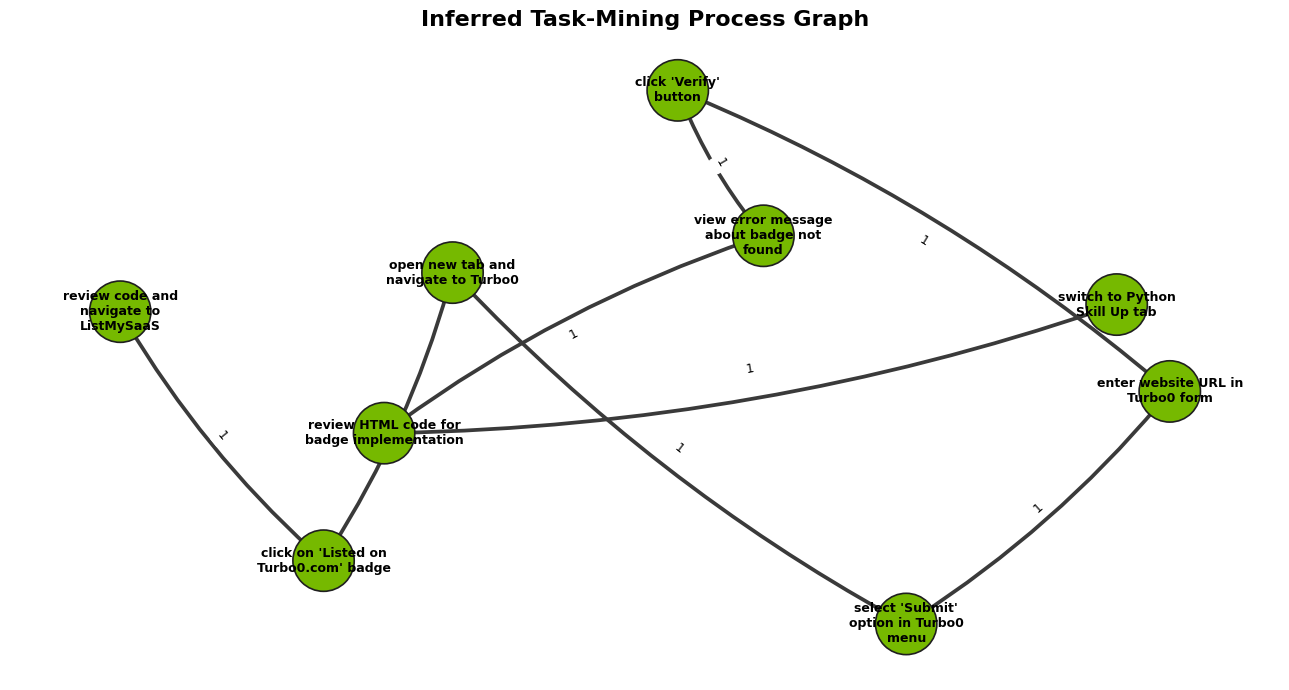

Saved graph to /content/nemotron_task_mining_process_graph.png


In [ ]:
def activity_order_key(row):
    try:
        return float(row.get("start_s", row.get("event_index", 0)))
    except Exception:
        return float(row.get("event_index", 0))


ordered = events_df.sort_values(by=list(events_df.columns.intersection(["start_s", "event_index"])))
activities = [str(value) for value in ordered["activity"].dropna().tolist()]
edge_counts = Counter(zip(activities, activities[1:]))

G = nx.DiGraph()
for activity in activities:
    G.add_node(activity, count=activities.count(activity))
for (src, dst), count in edge_counts.items():
    G.add_edge(src, dst, weight=count)

plt.figure(figsize=(13, 7))
pos = nx.spring_layout(G, seed=12, k=1.8)
node_sizes = [1600 + 350 * G.nodes[node].get("count", 1) for node in G.nodes]
edge_widths = [1.5 + 1.2 * G.edges[edge].get("weight", 1) for edge in G.edges]

nx.draw_networkx_nodes(G, pos, node_color="#76B900", node_size=node_sizes, edgecolors="#1f1f1f", linewidths=1.2)
nx.draw_networkx_edges(
    G,
    pos,
    arrows=True,
    arrowstyle="-|>",
    arrowsize=18,
    width=edge_widths,
    edge_color="#3a3a3a",
    connectionstyle="arc3,rad=0.08",
)
labels = {node: textwrap.fill(node, 20) for node in G.nodes}
nx.draw_networkx_labels(G, pos, labels=labels, font_size=9, font_weight="bold")
edge_labels = {(src, dst): data.get("weight", 1) for src, dst, data in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=9)

plt.title("Inferred Task-Mining Process Graph", fontsize=16, fontweight="bold")
plt.axis("off")
plt.tight_layout()
graph_path = Path("/content/nemotron_task_mining_process_graph.png")
plt.savefig(graph_path, dpi=180, bbox_inches="tight")
plt.show()
print(f"Saved graph to {graph_path}")


## Sanity Check Against Dataset Annotations

This section shows the human-readable annotations for the same time window. These annotations were not sent to the model. Use them to spot-check whether the inferred task log is plausible.


In [ ]:
def overlaps_window(annotation: dict, start_s: float, end_s: float) -> bool:
    return float(annotation.get("start_s", -1)) < end_s and float(annotation.get("end_s", -1)) > start_s


annotation_rows = [
    annotation
    for annotation in narration.get("annotations", [])
    if overlaps_window(annotation, CLIP_START_S, window_end_s)
]

annotations_df = pd.DataFrame(annotation_rows)
if not annotations_df.empty:
    annotations_df["clip_relative_start_s"] = annotations_df["start_s"] - CLIP_START_S
    annotations_df["clip_relative_end_s"] = annotations_df["end_s"] - CLIP_START_S
    display(
        annotations_df[
            [
                "clip_relative_start_s",
                "clip_relative_end_s",
                "app",
                "action",
                "intent",
                "details",
            ]
        ]
    )
else:
    print("No annotations overlap the selected clip window.")


,clip_relative_start_s,clip_relative_end_s,app,action,intent,details
0,-25.10,0.46,Antigravity,"Closed Quick Settings and returned to VS Code: with Antigravity extension, then clicked the Edge browser icon in taskbar.","To switch from system settings back to development work, then open the browser to view the local development server.",VS Code: shows 'Review Changes' tab with SiteFooter.tsx and index.html modifications for moving RankInPublic badge. Taskbar shows ListMy...
1,0.46,3.38,Microsoft Edge,"Switched to Microsoft Edge browser showing localhost:5174, then resized the window multiple times.","To view the ListMySaaS website and verify the badge placement changes, adjusting window size for better viewing.","URL: localhost:5174. Page shows 'ListMySaaS' header with Directory, Pricing, Submit, Dashboard, Sign In navigation. Main content area in..."
2,3.38,15.22,Microsoft Edge,Scrolled down the ListMySaaS page to view the footer section with featured badges.,To verify the RankInPublic badge placement and check the new 'The Key Tools' badge that was added in the code changes.,"Scrolled through 'As featured on' section showing badges: MarketingDB, Startup Fame, RankInPublic #1, NewTool.site, need, web-review.com..."
3,15.22,19.89,Brave Browser,"Clicked the Brave browser icon in taskbar, then switched between tabs including 'Python Skill Up' and 'EditlyCMS'.","To switch to Brave browser and navigate to a different tab, possibly to reference documentation or another project.",Switched from Microsoft Edge to Brave Browser. Initially on 'Python Skill Up - Brave' tab showing GeeksforGeeks course page with Week-1 ...
4,16.33,21.39,Brave Browser,"Clicked the browser tab labeled 'Your Personal Growth Playbook (0 → 1,000 Followers - First Leads)' to switch to it, then waited for the...",To view the downloaded PDF document about personal growth and follower acquisition strategies.,"PDF loaded from local file: C:/Users/user/Downloads/Your_Personal_Growth_Playbook_(0_?_1,000_Followers_-_First_Leads).pdf"
5,21.39,23.89,Brave Browser,"Scrolled down through the PDF document to read the content, then clicked on another browser tab.",To review the playbook content and then switch to a different task.,Viewed sections on 'Positioning' and 'Content Strategy' in the PDF
6,23.89,27.53,Brave Browser,Switched to the Turbo0 payment/verification page showing a backlink verification interface.,To verify a backlink for the ListMySaaS website on the Turbo0 platform.,"URL: turbo0.com/payment/BrefVQX7mbvSgaO6NK4kMP, showing 'Verify Backlink' button and website URL field with https://www.listmysaas.xyz/"
7,27.53,31.19,Microsoft Edge,"Switched to Microsoft Edge showing the ListMySaaS website, then resized the window.",To check the ListMySaaS website and prepare the window layout for side-by-side viewing.,"URL: localhost:5174, showing 'Discover the Best SaaS Tools | ListMySaaS' page with various featured badges"
8,31.19,38.20,Brave Browser,"Switched back to Brave Browser on the Turbo0 verification page, then clicked the 'Verify Backlink' button.",To attempt verification of the backlink for the ListMySaaS listing on Turbo0.,Clicked 'Verify Backlink' button on turbo0.com payment page
9,38.20,46.10,Antigravity,Switched to Antigravity IDE showing code changes in SiteFooter.tsx and index.html files.,To review code changes related to badge placement and backlink implementation.,"Reviewing changes to add badges for SaaSTool.site and TheKeyTools, with prompt to 'remove rank in public badge from bottom and replace i..."


## Optional: Use the Public Video URL Instead

The default path sends a compressed inline clip. If you want the NIM server to fetch the media, pass `PUBLIC_VIDEO_URL` as `video_url` and adjust the prompt to analyze the full recording. Inline clips are more reproducible in Colab because some public URLs can reject server-side fetches.

For longer clips, tune `media_io_kwargs`:

```python
"media_io_kwargs": {"video": {"num_frames": 24, "fps": -1}}
```

More frames improve temporal detail but increase latency and cost.


## Sources

- [Markov Sample Dataset - 100 Hours](https://huggingface.co/datasets/markov-ai/sample-100-hours): screen recordings, JSONL events, metadata, and annotations.
- [Markov Computer Use Large](https://huggingface.co/datasets/markov-ai/computer-use-large): larger companion dataset with tens of thousands of screen recordings.
- [NVIDIA NIM Nemotron 3 Nano Omni API documentation](https://docs.nvidia.com/nim/vision-language-models/1.7.0/examples/nemotron-3-nano-omni-30b-a3b-reasoning/api.html): `video_url`, base64 media, and video sampling with `media_io_kwargs`.
- Local reference: `nemotron_omni_parse_doc_intelligence_cookbook_colab.ipynb`.
